In [35]:
import pandas as pd

input_file = "../results/donor_triazine.csv" 
triazine_column = "SMILES"  
triazine_id_column = "Triazine_ID" 

df_triazines = pd.read_csv(input_file)

target_metals = {
    "Cu2+": "[Cu+2]",
    "Zn2+": "[Zn+2]",
    "Fe2+": "[Fe+2]",
    "Fe3+": "[Fe+3]"
}

paired_rows = []

for _, row in df_triazines.iterrows():
    triazine_smiles = row[triazine_column].strip()
    
    molecule_id = row[triazine_id_column].strip() 
    
    for metal_name, metal_smiles in target_metals.items():
        complex_smiles = f"{triazine_smiles}.{metal_smiles}"
        
        paired_rows.append({
            "molecule_id": molecule_id,
            "triazine_smiles": triazine_smiles,
            "metal": metal_name,
            "cmplx_smiles": complex_smiles
        })

df_predict = pd.DataFrame(paired_rows)
df_predict.to_csv("3k_triazine/predict_input.csv", index=False)

In [36]:
input_file = "3k_triazine/predictions_combined.csv"
df = pd.read_csv(input_file)

if "metal" not in df.columns:
    print("Mapping metals from complex SMILES...")
    metal_mapping = {
        "[Cu+2]": "Cu2+",
        "[Zn+2]": "Zn2+",
        "[Fe+2]": "Fe2+",
        "[Fe+3]": "Fe3+"
    }
    def detect_metal(smiles):
        for m_smiles, m_name in metal_mapping.items():
            if m_smiles in smiles:
                return m_name
        return "Other"
    
    df["metal"] = df["cmplx_smiles_neutral_std"].apply(detect_metal)

for metal, group in df.groupby("metal"):
    output_filename = f"predictions_{metal}.csv"
    target_col = [col for col in group.columns if "LgK1" in col]
    if target_col:
        group = group.sort_values(by=target_col[0], ascending=False)
        
    group.to_csv(f"3k_triazine/{output_filename}", index=False)
    

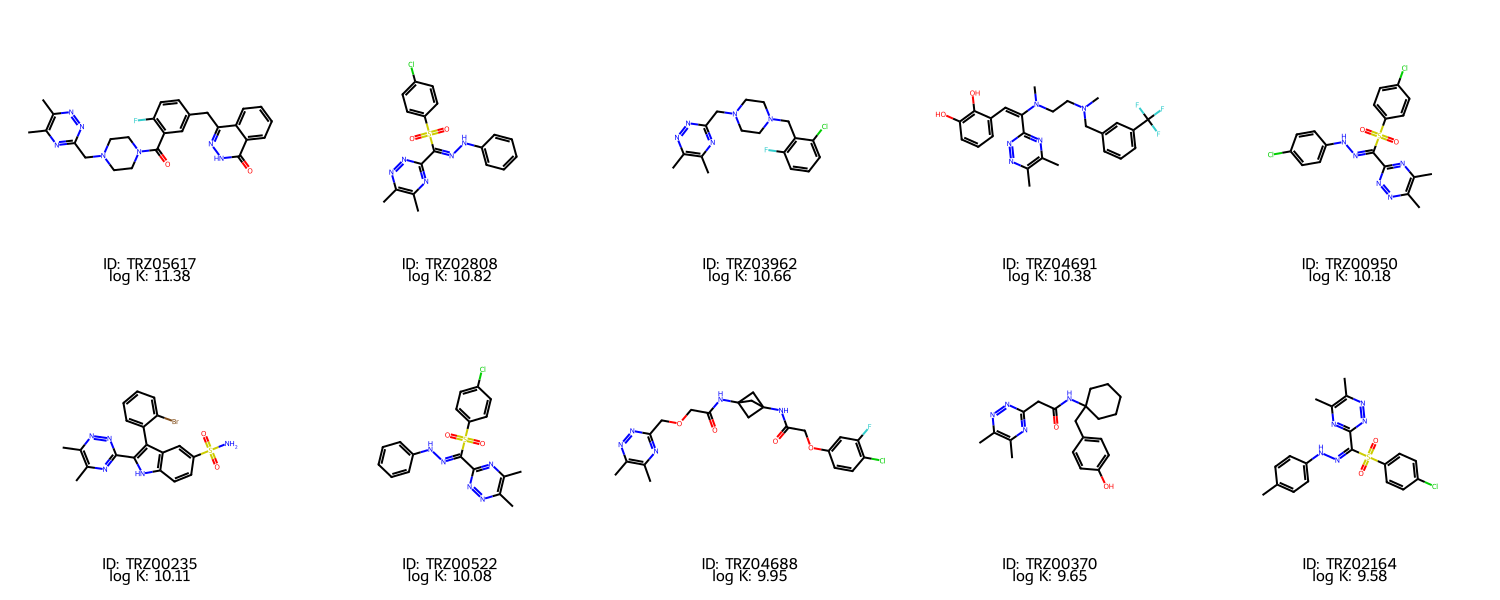

In [37]:
from rdkit import Chem
from rdkit.Chem import Draw

kdf = pd.read_csv("3k_triazine/predictions_Cu2+.csv")
top_10 = kdf.head(10)

mols = []
legends = []

for idx, row in top_10.iterrows():
    ligand_smiles = row["triazine_smiles"]
    mol_id = row.get("molecule_id", f"No.{idx+1}")
    lgk1_col = [col for col in row.index if "LgK1" in col]
    score = f"{row[lgk1_col[0]]:.2f}" if lgk1_col else "N/A"
    
    mol = Chem.MolFromSmiles(ligand_smiles)
    if mol:
        mols.append(mol)
        legends.append(f"ID: {mol_id}\nlog K: {score}")

Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

In [38]:
input_file = "../ML learning/trident_triazine/trident_triazine.csv" 
triazine_column = "SMILES"  
triazine_id_column = "Triazine_ID" 

trident_df = pd.read_csv(input_file)

target_metals = {
    "Cu2+": "[Cu+2]",
    "Zn2+": "[Zn+2]",
    "Fe2+": "[Fe+2]",
    "Fe3+": "[Fe+3]"
}

paired_rows = []

for _, row in trident_df.iterrows():
    triazine_smiles = row[triazine_column].strip()
    
    molecule_id = row[triazine_id_column].strip() 
    
    for metal_name, metal_smiles in target_metals.items():
        complex_smiles = f"{triazine_smiles}.{metal_smiles}"
        
        paired_rows.append({
            "molecule_id": molecule_id,
            "triazine_smiles": triazine_smiles,
            "metal": metal_name,
            "cmplx_smiles": complex_smiles
        })

df_predict = pd.DataFrame(paired_rows)
df_predict.to_csv("trident_triazine/trident_input.csv", index=False)

In [39]:
input_file = "trident_triazine/trident_predictions_combined.csv"
sept_df = pd.read_csv(input_file)

if "metal" not in sept_df.columns:
    metal_mapping = {
        "[Cu+2]": "Cu2+",
        "[Zn+2]": "Zn2+",
        "[Fe+2]": "Fe2+",
        "[Fe+3]": "Fe3+"
    }
    def detect_metal(smiles):
        for m_smiles, m_name in metal_mapping.items():
            if m_smiles in smiles:
                return m_name
        return "Other"
    sept_df["metal"] = sept_df["cmplx_smiles"].apply(detect_metal)

pred_col = [col for col in sept_df.columns if "LgK1" in col or "pred" in col.lower()][0]

for metal, group in sept_df.groupby("metal"):
    group = group.sort_values(by=pred_col, ascending=False)
   
    group.to_csv(f"trident_triazine/trident_predictions_{metal}.csv", index=False)

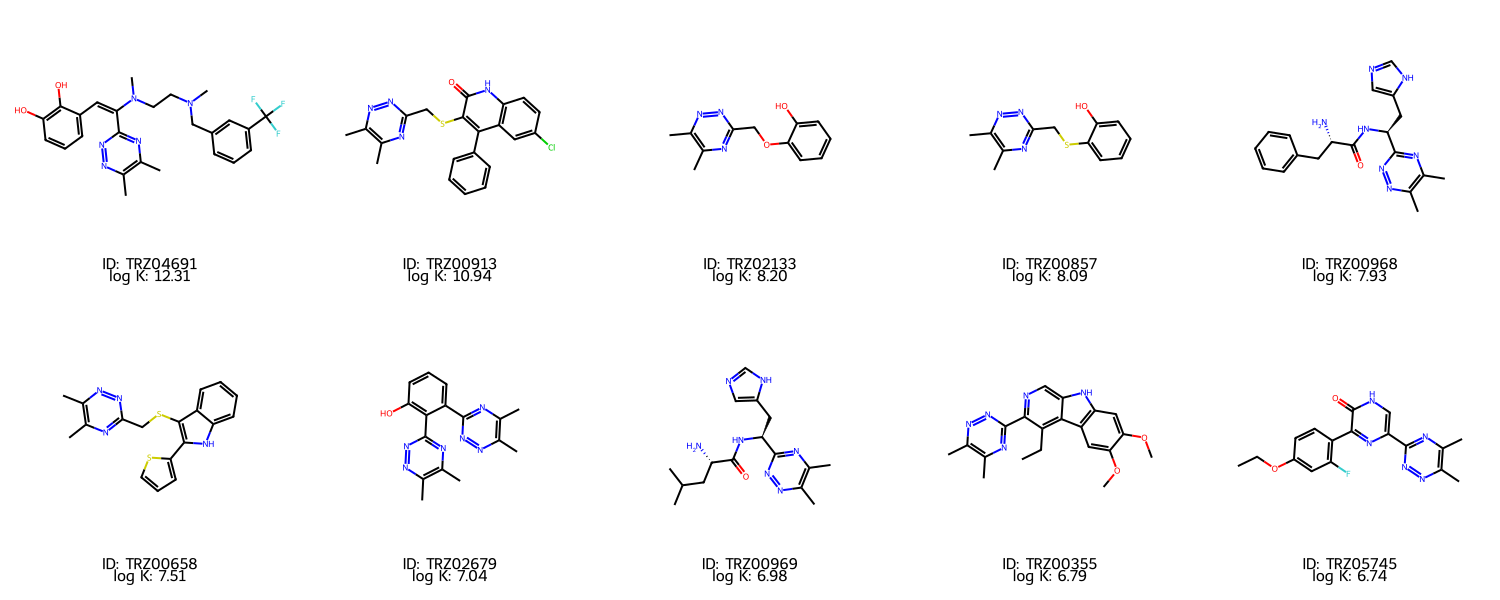

In [40]:
tridf = pd.read_csv("trident_triazine/trident_predictions_Cu2+.csv")
top_10 = tridf.head(10)

mols = []
legends = []

for idx, row in top_10.iterrows():
    ligand_smiles = row["triazine_smiles"]
    mol_id = row.get("molecule_id", f"No.{idx+1}")
    lgk1_col = [col for col in row.index if "LgK1" in col]
    score = f"{row[lgk1_col[0]]:.2f}" if lgk1_col else "N/A"
    
    mol = Chem.MolFromSmiles(ligand_smiles)
    if mol:
        mols.append(mol)
        legends.append(f"ID: {mol_id}\nlog K: {score}")

Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

In [41]:
top30_df = pd.read_csv("../results/metal_sensing_app/top_MS_candidates.csv")
tri_df = pd.read_csv("trident_triazine/trident_predictions_Cu2+.csv")

df_matched = tri_df[tri_df["triazine_smiles"].isin(top30_df["SMILES"].tolist())]

if df_matched.empty:
    print("Available columns in file:", tri_df.columns.tolist())
else:
    pred_col = [col for col in df_matched.columns if "LgK1" in col or "pred" in col.lower()][0]
    df_matched = df_matched.sort_values(by=pred_col, ascending=False)
   
    print(df_matched[["molecule_id", "metal", pred_col, "cmplx_smiles"]])
    df_matched.to_csv("top30_Cu2+_predictions.csv", index=False)
 

    molecule_id metal  Exp LgK1  \
17     TRZ00686  Cu2+  5.328498   
22     TRZ05734  Cu2+  4.850407   
33     TRZ00259  Cu2+  4.179868   
35     TRZ00376  Cu2+  4.098429   
40     TRZ00111  Cu2+  4.008733   
50     TRZ01194  Cu2+  3.869926   
51     TRZ02000  Cu2+  3.867066   
55     TRZ02802  Cu2+  3.696672   
56     TRZ00296  Cu2+  3.683400   
57     TRZ01080  Cu2+  3.526906   
61     TRZ02390  Cu2+  3.401810   
62     TRZ00374  Cu2+  3.332664   
63     TRZ00371  Cu2+  3.326878   
65     TRZ00127  Cu2+  3.313185   
73     TRZ00375  Cu2+  3.113885   
77     TRZ00112  Cu2+  2.931175   
88     TRZ01251  Cu2+  2.613567   
93     TRZ01527  Cu2+  2.557323   
97     TRZ00628  Cu2+  2.364519   
99     TRZ02396  Cu2+  2.282657   
118    TRZ00432  Cu2+  1.775674   
120    TRZ00116  Cu2+  1.695759   
125    TRZ00727  Cu2+  1.497284   
133    TRZ01544  Cu2+  1.295237   
143    TRZ02392  Cu2+  1.085988   
162    TRZ05498  Cu2+  0.573820   
168    TRZ01492  Cu2+  0.433645   
170    TRZ00117  Cu2

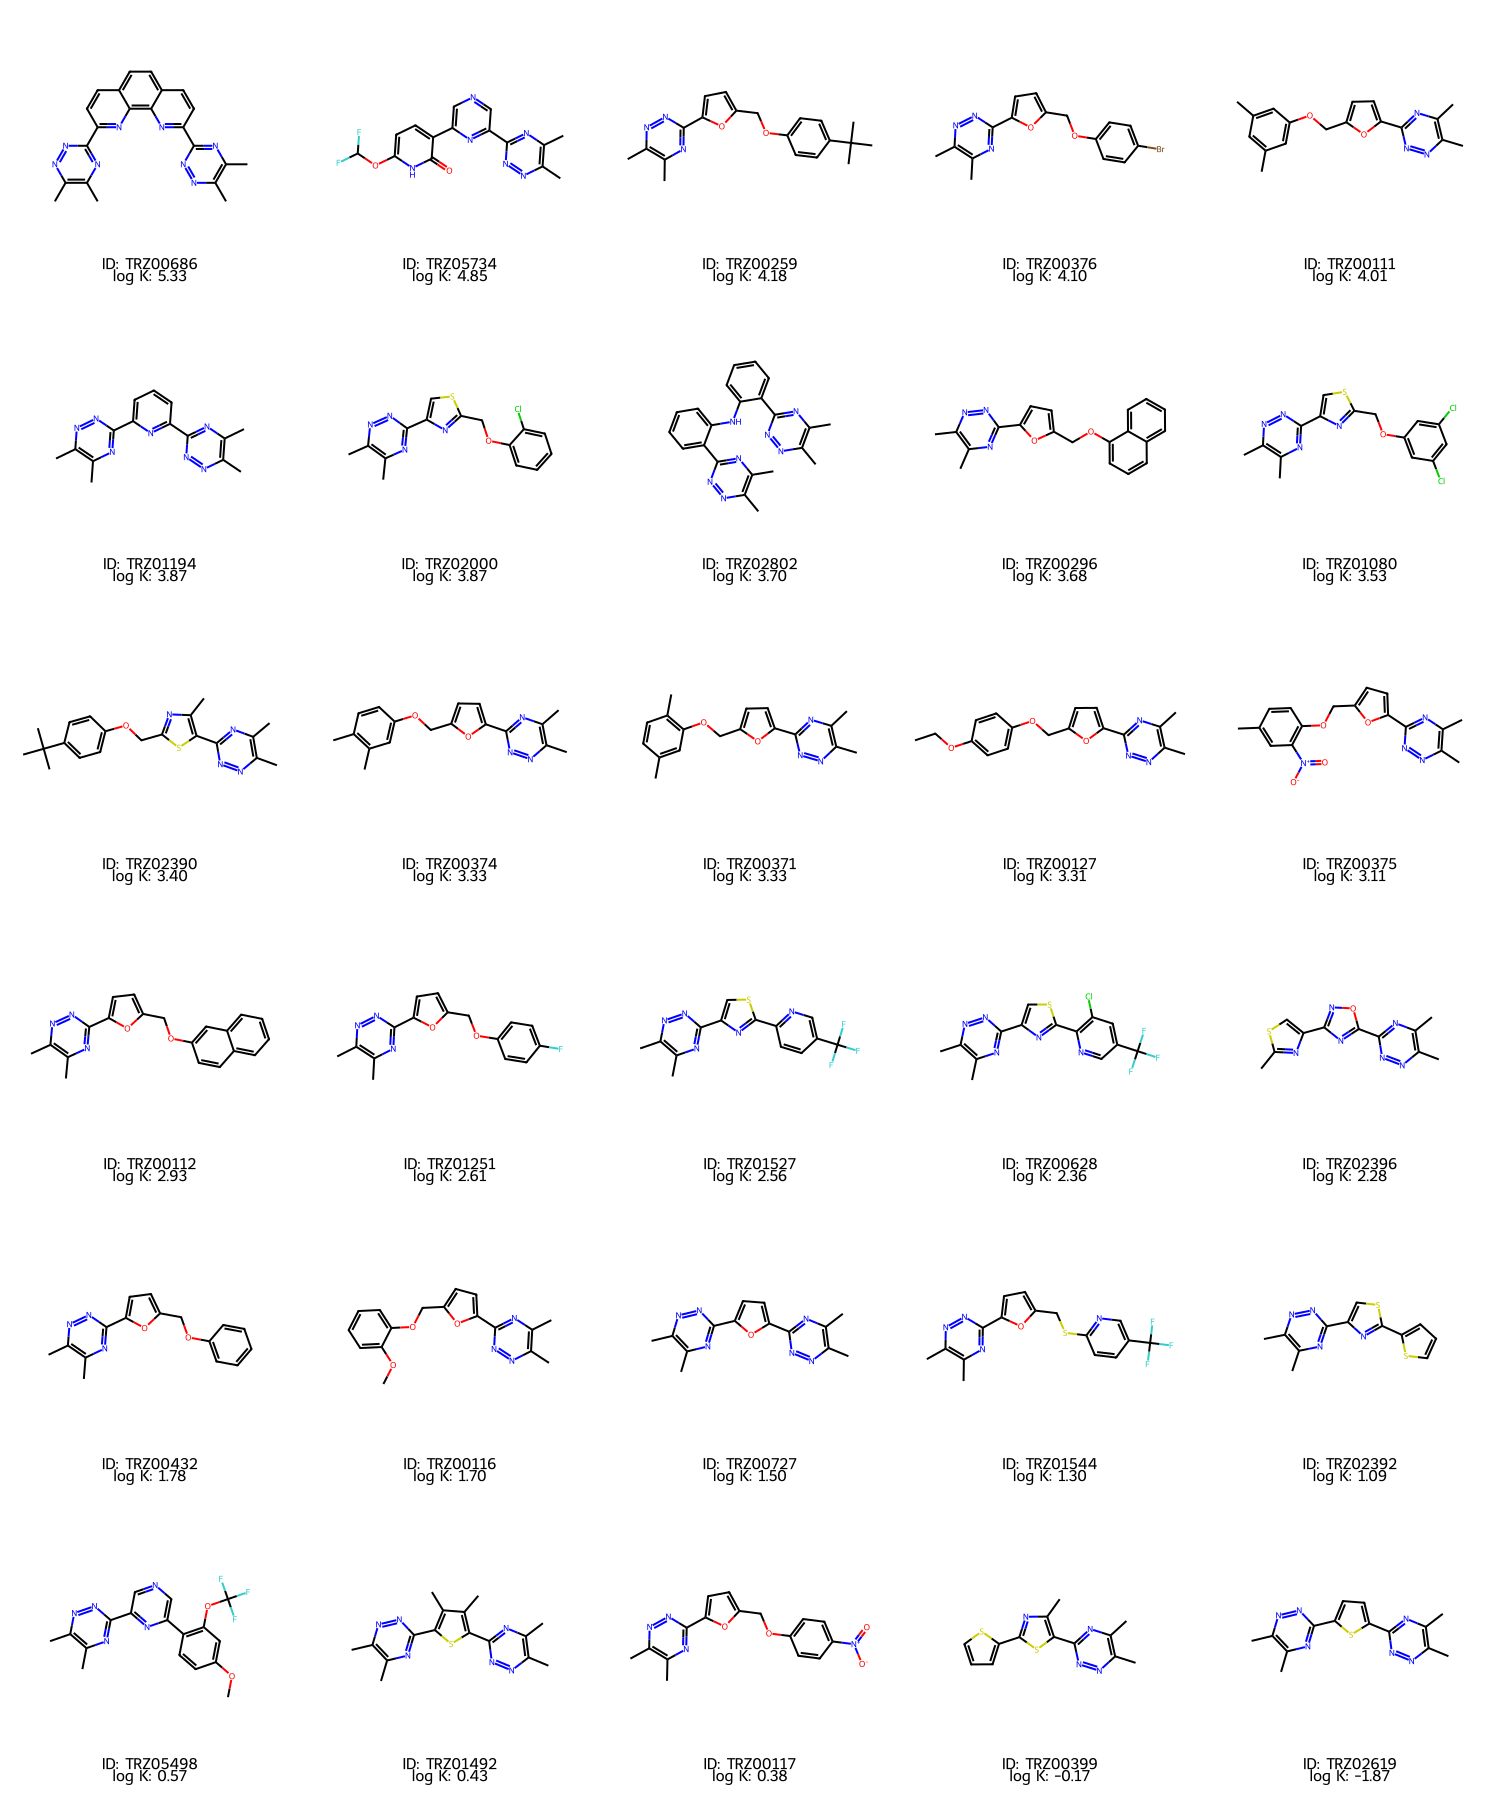

In [42]:
topdf = pd.read_csv("top30_Cu2+_predictions.csv")
top_10 = topdf.head(30)

mols = []
legends = []

for idx, row in top_10.iterrows():
    ligand_smiles = row["triazine_smiles"]
    mol_id = row.get("molecule_id", f"No.{idx+1}")
    lgk1_col = [col for col in row.index if "LgK1" in col]
    score = f"{row[lgk1_col[0]]:.2f}" if lgk1_col else "N/A"
    
    mol = Chem.MolFromSmiles(ligand_smiles)
    if mol:
        mols.append(mol)
        legends.append(f"ID: {mol_id}\nlog K: {score}")

Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(300, 300), 
    legends=legends
)

In [43]:
pred_col = [col for col in tri_df.columns if "LgK1" in col or "pred" in col.lower()][0]

tri_df["global_rank"] = tri_df[pred_col].rank(ascending=False, method="min").astype(int)
tri_df["percentile_top"] = (tri_df["global_rank"] / len(tri_df)) * 100

df_my_30 = tri_df[tri_df["molecule_id"].isin(topdf["molecule_id"])].copy()

df_my_30 = df_my_30.sort_values(by="global_rank")

print(df_my_30[["molecule_id", "metal", pred_col, "global_rank", "percentile_top"]].to_string(index=False))

molecule_id metal  Exp LgK1  global_rank  percentile_top
   TRZ00686  Cu2+  5.328498           18        8.571429
   TRZ05734  Cu2+  4.850407           23       10.952381
   TRZ00259  Cu2+  4.179868           34       16.190476
   TRZ00376  Cu2+  4.098429           36       17.142857
   TRZ00111  Cu2+  4.008733           41       19.523810
   TRZ01194  Cu2+  3.869926           51       24.285714
   TRZ02000  Cu2+  3.867066           52       24.761905
   TRZ02802  Cu2+  3.696672           56       26.666667
   TRZ00296  Cu2+  3.683400           57       27.142857
   TRZ01080  Cu2+  3.526906           58       27.619048
   TRZ02390  Cu2+  3.401810           62       29.523810
   TRZ00374  Cu2+  3.332664           63       30.000000
   TRZ00371  Cu2+  3.326878           64       30.476190
   TRZ00127  Cu2+  3.313185           66       31.428571
   TRZ00375  Cu2+  3.113885           74       35.238095
   TRZ00112  Cu2+  2.931175           78       37.142857
   TRZ01251  Cu2+  2.613567    